# Báo cáo tổng hợp task Phát — PhoWhisper-base LoRA và Tone-aware LoRA

Notebook này tổng hợp **kết quả thực đã chạy** cho phần Phát trong `Checklist SLP.md`. Mọi bảng và biểu đồ đều được đọc lại từ checkpoint, training log, benchmark manifest, prediction CSV và aggregate report trong repository; notebook không sinh metric hay kết quả giả.

**Phạm vi bắt buộc:** setup PhoWhisper-base LoRA, ordinary LoRA, tone-aware loss, ablation 5 giá trị λ, đánh giá clean/noisy, xuất prediction, tổng hợp metric và chọn best λ.

**Cách đọc notebook:**

1. Kiểm tra môi trường và artifact nguồn.
2. Đối chiếu các task trong checklist.
3. Phân tích quá trình training và ý nghĩa của 3 epoch.
4. Kiểm tra benchmark, trong đó có `data/noisy_eval`.
5. Phân tích prediction, WER/CER/TER/DER theo λ và SNR.
6. Giải thích vì sao λ=0.05 được chọn và các giới hạn của kết luận.


In [1]:
from pathlib import Path
from html import escape
import json
import math
import sys

import pandas as pd
import yaml
from IPython.display import HTML, Markdown, SVG, display

ROOT = Path.cwd().resolve()
assert (ROOT / "Checklist SLP.md").exists(), f"Hãy chạy notebook từ repository root, hiện tại: {ROOT}"

REPORT_DIR = ROOT / "outputs" / "phat" / "reports"
PREDICTION_DIR = ROOT / "outputs" / "phat" / "predictions"
LOG_DIR = ROOT / "outputs" / "phat" / "logs"
CHECKPOINT_DIR = ROOT / "outputs" / "phat" / "checkpoints"
MANIFEST_PATH = ROOT / "outputs" / "benchmark" / "benchmark_manifest.csv"

required_sources = [
    MANIFEST_PATH,
    REPORT_DIR / "lambda_ablation_results.csv",
    REPORT_DIR / "best_lambda_report.md",
]
missing_sources = [str(path.relative_to(ROOT)) for path in required_sources if not path.exists()]
assert not missing_sources, f"Thiếu artifact nguồn: {missing_sources}"


def show_table(frame: pd.DataFrame, *, decimals: int = 6) -> None:
    formatted = frame.copy()
    for column in formatted.select_dtypes(include="number").columns:
        formatted[column] = formatted[column].map(
            lambda value: f"{value:.{decimals}f}" if isinstance(value, float) else value
        )
    display(HTML(formatted.to_html(index=False, border=0, classes="dataframe phat-table")))


def line_chart_svg(
    x_labels: list[str],
    series: dict[str, list[float]],
    *,
    title: str,
    y_label: str,
    width: int = 960,
    height: int = 440,
) -> SVG:
    if not x_labels or not series:
        raise ValueError("Biểu đồ cần ít nhất một điểm dữ liệu")
    lengths = {len(values) for values in series.values()}
    if lengths != {len(x_labels)}:
        raise ValueError("Các series phải có cùng số điểm với x_labels")

    colors = ["#2563eb", "#dc2626", "#059669", "#7c3aed", "#ea580c", "#0891b2"]
    left, right, top, bottom = 72, 190, 52, 72
    plot_width = width - left - right
    plot_height = height - top - bottom
    all_values = [float(value) for values in series.values() for value in values]
    y_min = min(0.0, min(all_values))
    y_max = max(all_values)
    if math.isclose(y_min, y_max):
        y_max = y_min + 1.0
    padding = (y_max - y_min) * 0.08
    y_max += padding

    def x_pos(index: int) -> float:
        if len(x_labels) == 1:
            return left + plot_width / 2
        return left + index * plot_width / (len(x_labels) - 1)

    def y_pos(value: float) -> float:
        return top + (y_max - value) * plot_height / (y_max - y_min)

    svg: list[str] = [
        f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}" viewBox="0 0 {width} {height}">',
        '<rect width="100%" height="100%" fill="#ffffff" rx="12"/>',
        f'<text x="{left}" y="28" font-family="Segoe UI,Arial" font-size="20" font-weight="700" fill="#111827">{escape(title)}</text>',
    ]

    for tick in range(6):
        value = y_min + (y_max - y_min) * tick / 5
        y = y_pos(value)
        svg.append(f'<line x1="{left}" y1="{y:.2f}" x2="{left + plot_width}" y2="{y:.2f}" stroke="#e5e7eb"/>')
        svg.append(f'<text x="{left - 10}" y="{y + 4:.2f}" text-anchor="end" font-family="Segoe UI,Arial" font-size="11" fill="#6b7280">{value:.3f}</text>')

    tick_indexes = sorted(set([0, len(x_labels) - 1] + [round((len(x_labels) - 1) * fraction / 5) for fraction in range(1, 5)]))
    for index in tick_indexes:
        x = x_pos(index)
        label = escape(str(x_labels[index]))
        svg.append(f'<line x1="{x:.2f}" y1="{top + plot_height}" x2="{x:.2f}" y2="{top + plot_height + 5}" stroke="#9ca3af"/>')
        svg.append(f'<text x="{x:.2f}" y="{top + plot_height + 22}" text-anchor="middle" font-family="Segoe UI,Arial" font-size="11" fill="#4b5563">{label}</text>')

    for series_index, (name, values) in enumerate(series.items()):
        color = colors[series_index % len(colors)]
        points = " ".join(f"{x_pos(index):.2f},{y_pos(float(value)):.2f}" for index, value in enumerate(values))
        svg.append(f'<polyline points="{points}" fill="none" stroke="{color}" stroke-width="2.4" stroke-linejoin="round" stroke-linecap="round"/>')
        if len(values) <= 12:
            for index, value in enumerate(values):
                svg.append(f'<circle cx="{x_pos(index):.2f}" cy="{y_pos(float(value)):.2f}" r="3.5" fill="{color}"/>')
        legend_y = top + 20 + series_index * 26
        svg.append(f'<line x1="{left + plot_width + 22}" y1="{legend_y}" x2="{left + plot_width + 48}" y2="{legend_y}" stroke="{color}" stroke-width="3"/>')
        svg.append(f'<text x="{left + plot_width + 56}" y="{legend_y + 4}" font-family="Segoe UI,Arial" font-size="12" fill="#374151">{escape(name)}</text>')

    svg.extend(
        [
            f'<line x1="{left}" y1="{top}" x2="{left}" y2="{top + plot_height}" stroke="#6b7280"/>',
            f'<line x1="{left}" y1="{top + plot_height}" x2="{left + plot_width}" y2="{top + plot_height}" stroke="#6b7280"/>',
            f'<text transform="translate(18 {top + plot_height / 2}) rotate(-90)" text-anchor="middle" font-family="Segoe UI,Arial" font-size="12" fill="#4b5563">{escape(y_label)}</text>',
            '</svg>',
        ]
    )
    return SVG("".join(svg))


environment_table = pd.DataFrame(
    [
        {"Thuộc tính": "Python executable", "Giá trị": sys.executable},
        {"Thuộc tính": "Python version", "Giá trị": sys.version.split()[0]},
        {"Thuộc tính": "Repository root", "Giá trị": str(ROOT)},
        {"Thuộc tính": "Aggregate result", "Giá trị": str((REPORT_DIR / "lambda_ablation_results.csv").relative_to(ROOT))},
        {"Thuộc tính": "Best-lambda report", "Giá trị": str((REPORT_DIR / "best_lambda_report.md").relative_to(ROOT))},
    ]
)
show_table(environment_table)


Thuộc tính,Giá trị
Python executable,C:\Users\phath\.conda\envs\slp\python.exe
Python version,3.11.15
Repository root,D:\FPT_UNIVERSITY\Ky 7\SLP301\Midterm\SLP
Aggregate result,outputs\phat\reports\lambda_ablation_results.csv
Best-lambda report,outputs\phat\reports\best_lambda_report.md


## 1. Đối chiếu các công việc của Phát trong Checklist

Bảng dưới đây chỉ bao gồm phần bắt buộc của **Phát**. Hai thí nghiệm PhoWhisper-tiny/small được checklist đánh dấu optional nên không dùng để xác định trạng thái hoàn thành P0.


In [2]:
checklist_mapping = pd.DataFrame(
    [
        ["Setup PhoWhisper-base LoRA", "configs/phat/base.yaml; src/vitonesr/phat/modeling.py", "Đã triển khai và chạy thật"],
        ["Ordinary LoRA (λ=0)", "ckpt_lora_ordinary_lambda0/final", "3 epoch, 2.187 steps"],
        ["Tone-aware LoRA", "src/vitonesr/phat/losses.py; tone_head.pt", "4 checkpoint λ>0"],
        ["Ablation λ={0, 0.05, 0.1, 0.3, 0.5}", "configs/phat/lambda_*.yaml", "5/5 run hoàn tất"],
        ["Evaluate clean + noisy", "outputs/benchmark/benchmark_manifest.csv", "5 × 1.500 inference"],
        ["Prediction từng λ", "outputs/phat/predictions/*.csv", "5 file đúng schema"],
        ["Tổng hợp kết quả", "lambda_ablation_results.csv", "110 aggregate rows"],
        ["Chọn best λ", "best_lambda_report.md", "λ=0.05"],
    ],
    columns=["Task trong Checklist", "Artifact chính", "Kết quả"],
)
show_table(checklist_mapping)


Task trong Checklist,Artifact chính,Kết quả
Setup PhoWhisper-base LoRA,configs/phat/base.yaml; src/vitonesr/phat/modeling.py,Đã triển khai và chạy thật
Ordinary LoRA (λ=0),ckpt_lora_ordinary_lambda0/final,"3 epoch, 2.187 steps"
Tone-aware LoRA,src/vitonesr/phat/losses.py; tone_head.pt,4 checkpoint λ>0
"Ablation λ={0, 0.05, 0.1, 0.3, 0.5}",configs/phat/lambda_*.yaml,5/5 run hoàn tất
Evaluate clean + noisy,outputs/benchmark/benchmark_manifest.csv,5 × 1.500 inference
Prediction từng λ,outputs/phat/predictions/*.csv,5 file đúng schema
Tổng hợp kết quả,lambda_ablation_results.csv,110 aggregate rows
Chọn best λ,best_lambda_report.md,λ=0.05


## 2. Kết quả training của 5 giá trị λ

- **λ=0** là ordinary LoRA: `total_loss = asr_loss`, không có tone head.
- **λ>0** là tone-aware LoRA: `total_loss = asr_loss + λ × tone_loss`.
- Mỗi run sử dụng cùng seed, batch size, số epoch và learning-rate schedule để phép so sánh ablation công bằng.
- `tone_loss` không phải loss giả: nó được tính từ decoder hidden state, tone head và tone label trích từ transcript tiếng Việt.


In [3]:
run_specs = [
    {"lambda": 0.0, "train_type": "ordinary_lora", "root": "ckpt_lora_ordinary_lambda0", "log": "train_lora_ordinary_lambda0.csv"},
    {"lambda": 0.05, "train_type": "tone_aware_lora", "root": "ckpt_tone_lora_lambda_005", "log": "train_tone_lora_lambda_005.csv"},
    {"lambda": 0.1, "train_type": "tone_aware_lora", "root": "ckpt_tone_lora_lambda_01", "log": "train_tone_lora_lambda_01.csv"},
    {"lambda": 0.3, "train_type": "tone_aware_lora", "root": "ckpt_tone_lora_lambda_03", "log": "train_tone_lora_lambda_03.csv"},
    {"lambda": 0.5, "train_type": "tone_aware_lora", "root": "ckpt_tone_lora_lambda_05", "log": "train_tone_lora_lambda_05.csv"},
]

training_rows = []
training_logs: dict[float, pd.DataFrame] = {}
required_checkpoint_files = {
    "adapter/adapter_model.safetensors",
    "adapter/adapter_config.json",
    "processor/tokenizer.json",
    "optimizer.pt",
    "scheduler.pt",
    "scaler.pt",
    "rng_state.pt",
    "resolved_config.yaml",
    "trainer_state.json",
}

for spec in run_specs:
    final_dir = CHECKPOINT_DIR / spec["root"] / "final"
    state = json.loads((final_dir / "trainer_state.json").read_text(encoding="utf-8"))
    metrics = pd.read_csv(LOG_DIR / spec["log"])
    training_logs[spec["lambda"]] = metrics
    missing = sorted(path for path in required_checkpoint_files if not (final_dir / path).exists())
    assert not missing, f"Checkpoint λ={spec['lambda']} thiếu: {missing}"
    tone_head_exists = (final_dir / "tone_head.pt").exists()
    assert tone_head_exists == (spec["lambda"] > 0), f"Tone head không đúng cho λ={spec['lambda']}"
    assert state["global_step"] == 2187 and state["epoch"] == 3 and state["next_batch_index"] == 0
    assert len(metrics) == 219
    last = metrics.iloc[-1]
    training_rows.append(
        {
            "λ": spec["lambda"],
            "train_type": spec["train_type"],
            "epoch hoàn tất": state["epoch"],
            "optimizer steps": state["global_step"],
            "log rows": len(metrics),
            "tone head": tone_head_exists,
            "ASR loss cuối log": float(last["asr_loss"]),
            "tone loss cuối log": float(last["tone_loss"]),
            "total loss cuối log": float(last["total_loss"]),
        }
    )

training_summary = pd.DataFrame(training_rows)
show_table(training_summary)


λ,train_type,epoch hoàn tất,optimizer steps,log rows,tone head,ASR loss cuối log,tone loss cuối log,total loss cuối log
0.000000,ordinary_lora,3,2187,219,False,0.068728,0.000000,0.068728
0.050000,tone_aware_lora,3,2187,219,True,0.069388,1.013631,0.120070
0.100000,tone_aware_lora,3,2187,219,True,0.070202,0.982067,0.168408
0.300000,tone_aware_lora,3,2187,219,True,0.078728,0.876691,0.341736
0.500000,tone_aware_lora,3,2187,219,True,0.092823,0.796029,0.490838


### Vì sao có 3 epoch?

Dataset train có 11.660 mẫu. Với batch size 16, mỗi epoch có khoảng 729 optimizer steps; 3 epoch tạo đúng 2.187 steps. Đây là budget cố định cho cả 5 λ, phù hợp với LoRA fine-tuning trên backbone đã pretrained và giúp tránh so sánh bất công giữa các λ.

**Cần lưu ý:** loss cuối của các λ không thể so trực tiếp như cùng một đại lượng, vì λ>0 cộng thêm tone loss với trọng số khác nhau. Chất lượng cuối phải được kết luận từ WER/CER/TER/DER trên benchmark, không chỉ từ training loss.


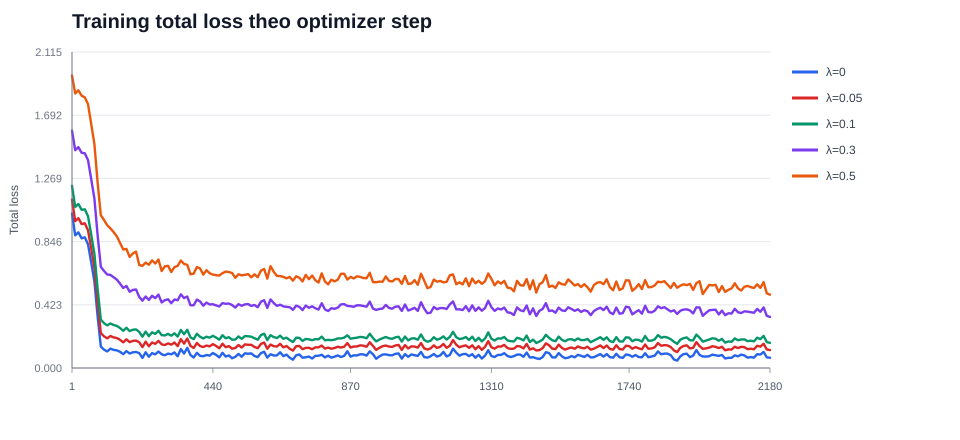

In [4]:
steps = training_logs[0.0]["global_step"].astype(int).astype(str).tolist()
loss_series = {
    f"λ={value:g}": training_logs[value]["total_loss"].astype(float).tolist()
    for value in [0.0, 0.05, 0.1, 0.3, 0.5]
}
display(
    line_chart_svg(
        steps,
        loss_series,
        title="Training total loss theo optimizer step",
        y_label="Total loss",
    )
)


**Ý nghĩa biểu đồ:** loss của tất cả run giảm mạnh ở đầu quá trình rồi ổn định. λ càng lớn thì `total_loss` ban đầu càng cao vì thành phần `λ × tone_loss` lớn hơn. Điều này không tự động có nghĩa model λ lớn kém hơn; phép đo benchmark phía dưới mới là tiêu chí quyết định.


## 3. Benchmark clean/noisy và vai trò của `data/noisy_eval`

Training trộn VIVOS và MUSAN động theo seed/config. Ngược lại, evaluation đọc benchmark cố định từ manifest. Các mẫu noisy trong manifest trỏ trực tiếp vào `data/noisy_eval`, nhờ vậy cả 5 checkpoint được đánh giá trên cùng audio và phép so sánh không bị thay đổi noise ngẫu nhiên giữa các λ.


In [5]:
manifest = pd.read_csv(MANIFEST_PATH)
manifest["snr"] = manifest["snr"].astype(str)
snr_order = ["clean", "20", "10", "5", "0"]

coverage_rows = []
for snr in snr_order:
    subset = manifest[manifest["snr"] == snr]
    coverage_rows.append(
        {
            "Điều kiện": "Clean" if snr == "clean" else f"{snr} dB",
            "Số mẫu": len(subset),
            "Audio tồn tại": int(subset["audio_path"].map(lambda value: (ROOT / value).exists()).sum()),
            "Thuộc data/noisy_eval": int(subset["audio_path"].str.replace("\\", "/", regex=False).str.startswith("data/noisy_eval/").sum()),
        }
    )

coverage = pd.DataFrame(coverage_rows)
assert len(manifest) == 1500
assert coverage["Số mẫu"].tolist() == [300, 300, 300, 300, 300]
assert coverage["Audio tồn tại"].sum() == 1500
assert coverage["Thuộc data/noisy_eval"].sum() == 1200
show_table(coverage, decimals=0)


Điều kiện,Số mẫu,Audio tồn tại,Thuộc data/noisy_eval
Clean,300,300,0
20 dB,300,300,300
10 dB,300,300,300
5 dB,300,300,300
0 dB,300,300,300


**Kết luận:** `data/noisy_eval` đã được sử dụng thật cho 1.200 lượt audio của mỗi checkpoint (300 mẫu ở từng SNR 20/10/5/0 dB). Tổng cộng riêng phần noisy tạo ra 6.000 lượt inference qua 5 checkpoint; 300 clean còn lại tạo thêm 1.500 lượt inference.


## 4. Kiểm tra 5 file prediction

Checklist yêu cầu schema chung chính xác. Cell tiếp theo kiểm tra số dòng, thứ tự cột, metadata, reference và hypothesis của từng file.


In [6]:
expected_schema = [
    "utt_id", "dataset", "model", "model_size", "train_type",
    "lambda", "seed", "snr", "noise_type", "ref", "hyp",
]
prediction_files = [
    "pred_lora_ordinary_lambda0.csv",
    "pred_tone_lora_lambda_005.csv",
    "pred_tone_lora_lambda_01.csv",
    "pred_tone_lora_lambda_03.csv",
    "pred_tone_lora_lambda_05.csv",
]

prediction_rows = []
for filename in prediction_files:
    frame = pd.read_csv(PREDICTION_DIR / filename, keep_default_na=False)
    assert list(frame.columns) == expected_schema, f"Sai schema: {filename}"
    assert len(frame) == 1500
    assert not frame["ref"].str.strip().eq("").any()
    assert not frame["hyp"].str.strip().eq("").any()
    snr_counts = frame["snr"].astype(str).value_counts().to_dict()
    assert all(snr_counts.get(snr, 0) == 300 for snr in snr_order)
    prediction_rows.append(
        {
            "File": filename,
            "Rows": len(frame),
            "Columns": len(frame.columns),
            "model": ",".join(sorted(frame["model"].unique())),
            "model_size": ",".join(sorted(frame["model_size"].unique())),
            "train_type": ",".join(sorted(frame["train_type"].unique())),
            "λ": ",".join(sorted(frame["lambda"].astype(str).unique())),
            "Empty ref/hyp": int(frame["ref"].str.strip().eq("").sum() + frame["hyp"].str.strip().eq("").sum()),
        }
    )

prediction_summary = pd.DataFrame(prediction_rows)
assert prediction_summary["Rows"].sum() == 7500
show_table(prediction_summary, decimals=0)


File,Rows,Columns,model,model_size,train_type,λ,Empty ref/hyp
pred_lora_ordinary_lambda0.csv,1500,11,phowhisper,base,ordinary_lora,0,0
pred_tone_lora_lambda_005.csv,1500,11,phowhisper,base,tone_aware_lora,0.05,0
pred_tone_lora_lambda_01.csv,1500,11,phowhisper,base,tone_aware_lora,0.1,0
pred_tone_lora_lambda_03.csv,1500,11,phowhisper,base,tone_aware_lora,0.3,0
pred_tone_lora_lambda_05.csv,1500,11,phowhisper,base,tone_aware_lora,0.5,0


## 5. Kết quả tổng thể theo λ

- **WER:** tỷ lệ lỗi từ; phản ánh chất lượng nhận dạng nội dung ở mức từ.
- **CER:** tỷ lệ lỗi ký tự; nhạy với lỗi chính tả và dấu hơn WER.
- **TER:** lỗi thanh điệu; là metric trọng tâm của tone-aware training.
- **DER:** lỗi dấu/diacritic; đo sai khác dấu tiếng Việt.
- **FCER:** lỗi phụ âm cuối.
- **SWDR:** lỗi xóa từ ngắn.

Các giá trị càng thấp càng tốt.


In [7]:
results = pd.read_csv(REPORT_DIR / "lambda_ablation_results.csv")
results["snr"] = results["snr"].astype(str)
metric_columns = ["wer", "cer", "ter", "der", "fcer", "swdr"]
assert len(results) == 110
assert sorted(results["lambda"].unique().tolist()) == [0.0, 0.05, 0.1, 0.3, 0.5]
assert results[metric_columns].notna().all().all()
assert results[metric_columns].map(math.isfinite).all().all()

overall = (
    results[(results["split"] == "all") & (results["snr"] == "all") & (results["noise_type"] == "all")]
    .sort_values("lambda")
    [["lambda", "train_type", "num_samples"] + metric_columns]
    .reset_index(drop=True)
)
assert len(overall) == 5 and overall["num_samples"].eq(1500).all()
show_table(overall.rename(columns={"lambda": "λ", "num_samples": "samples"}))


λ,train_type,samples,wer,cer,ter,der,fcer,swdr
0.000000,ordinary_lora,1500,0.132462,0.072891,0.098765,0.035643,0.076354,0.005674
0.050000,tone_aware_lora,1500,0.128870,0.070175,0.094454,0.031365,0.076486,0.006028
0.100000,tone_aware_lora,1500,0.130372,0.071688,0.095173,0.033010,0.075826,0.005674
0.300000,tone_aware_lora,1500,0.139517,0.075978,0.102750,0.039656,0.078071,0.006383
0.500000,tone_aware_lora,1500,0.154801,0.088031,0.118746,0.049546,0.085601,0.006028


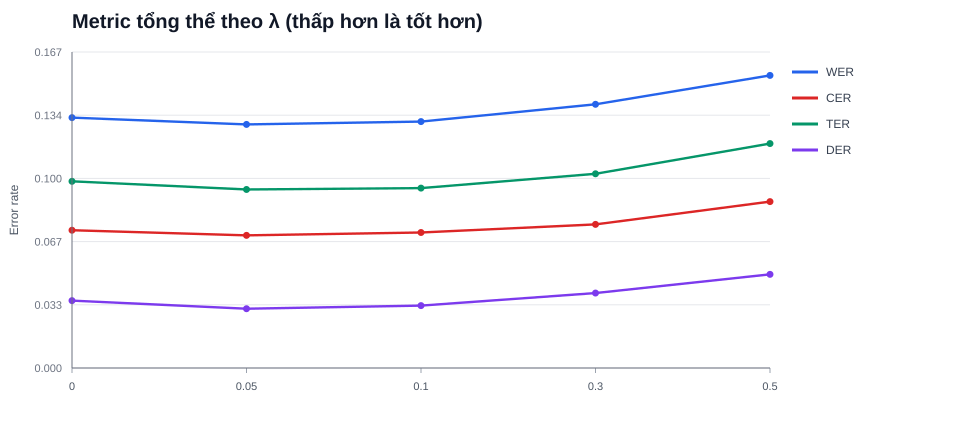

In [8]:
display(
    line_chart_svg(
        [f"{value:g}" for value in overall["lambda"]],
        {
            "WER": overall["wer"].astype(float).tolist(),
            "CER": overall["cer"].astype(float).tolist(),
            "TER": overall["ter"].astype(float).tolist(),
            "DER": overall["der"].astype(float).tolist(),
        },
        title="Metric tổng thể theo λ (thấp hơn là tốt hơn)",
        y_label="Error rate",
    )
)


**Ý nghĩa:** λ=0.05 cải thiện đồng thời WER, CER, TER và DER so với ordinary LoRA λ=0. Khi λ tăng tới 0.3–0.5, WER/CER và tone metrics đều xấu đi. Điều này cho thấy tone supervision có lợi khi được cân bằng vừa phải, nhưng trọng số quá lớn có thể làm model ưu tiên tone objective quá mức và ảnh hưởng ASR chính.


## 6. Độ bền theo từng mức SNR

SNR càng thấp thì tín hiệu càng nhiễu. `0 dB` là điều kiện khó nhất vì năng lượng speech và noise xấp xỉ nhau. Bảng và biểu đồ sau cho thấy WER theo clean/20/10/5/0 dB.


SNR,λ=0,λ=0.05,λ=0.1,λ=0.3,λ=0.5
clean,0.074461,0.073481,0.074788,0.080340,0.087851
20,0.083605,0.084585,0.085238,0.089811,0.099935
10,0.105487,0.103854,0.102221,0.104180,0.112345
5,0.149575,0.145983,0.150229,0.154148,0.170150
0,0.249184,0.236447,0.239386,0.269105,0.303723


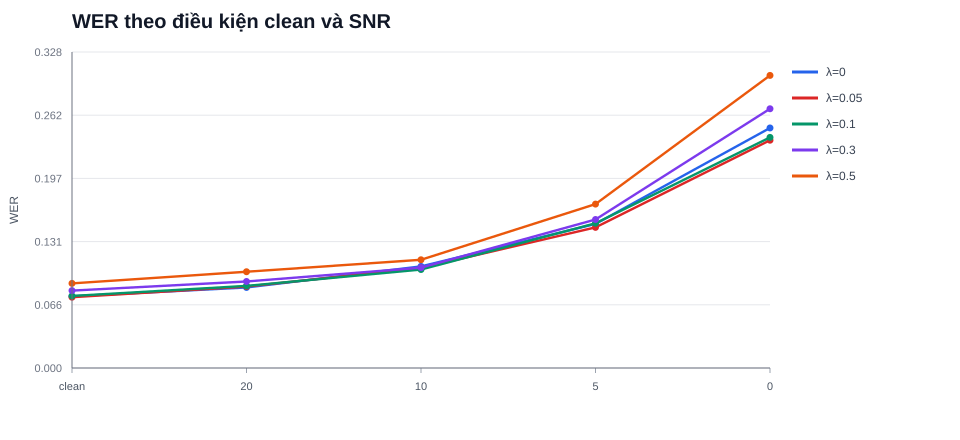

In [9]:
clean_snr_rows = results[
    (results["split"] == "clean")
    & (results["snr"] == "clean")
    & (results["noise_type"] == "clean")
].copy()
noisy_snr_rows = results[
    (results["split"] == "noisy")
    & (results["noise_type"] == "all")
    & (results["snr"].isin(["20", "10", "5", "0"]))
].copy()
snr_rows = pd.concat([clean_snr_rows, noisy_snr_rows], ignore_index=True)
assert len(snr_rows) == len(snr_order) * len(overall)
snr_rows["snr"] = pd.Categorical(snr_rows["snr"], categories=snr_order, ordered=True)
wer_by_snr = snr_rows.pivot(index="snr", columns="lambda", values="wer").reindex(snr_order)
assert wer_by_snr.notna().all().all()
wer_table = wer_by_snr.reset_index().rename(columns={"snr": "SNR"})
wer_table.columns = ["SNR"] + [f"λ={float(value):g}" for value in wer_by_snr.columns]
show_table(wer_table)

display(
    line_chart_svg(
        snr_order,
        {f"λ={float(value):g}": wer_by_snr[value].astype(float).tolist() for value in wer_by_snr.columns},
        title="WER theo điều kiện clean và SNR",
        y_label="WER",
    )
)


**Ý nghĩa:** tất cả model đều suy giảm khi SNR giảm, đặc biệt tại 0 dB. λ=0.05 giữ WER thấp hơn λ=0 ở tổng thể và cải thiện rõ nhất ở điều kiện khó, trong khi λ=0.5 suy giảm mạnh. Kết quả này phù hợp với mục tiêu chọn λ dựa trên low-SNR thay vì chỉ nhìn clean WER.


## 7. Chọn best λ theo TER/DER low-SNR và WER/CER guard

Selector sử dụng trung bình TER và DER ở **0 dB + 5 dB**, sau đó kiểm tra WER/CER tổng thể không tăng quá ngưỡng so với λ=0. Trọng số và guard lấy từ `configs/phat/base.yaml`.


λ,low_snr_ter,low_snr_der,clean_wer,clean_cer,guard_wer,guard_cer,delta_wer,delta_cer,score,eligible
0.000000,0.153854,0.067242,0.074461,0.032719,0.132462,0.072891,0.000000,0.000000,0.110548,True
0.050000,0.144544,0.056159,0.073481,0.032796,0.128870,0.070175,-0.003592,-0.002716,0.100351,True
0.100000,0.148953,0.061297,0.074788,0.033413,0.130372,0.071688,-0.002090,-0.001204,0.105125,True
0.300000,0.159571,0.076822,0.080340,0.035265,0.139517,0.075978,0.007054,0.003087,0.118196,True
0.500000,0.184847,0.100751,0.087851,0.038738,0.154801,0.088031,0.022338,0.015140,0.142799,True


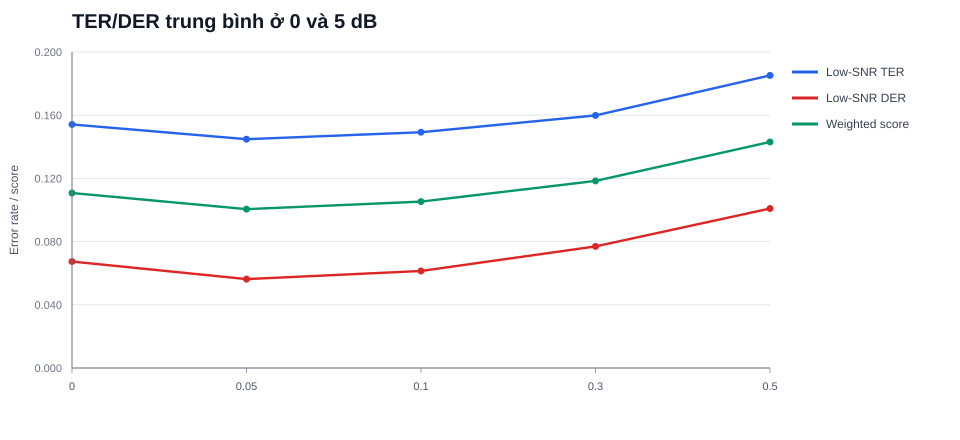

In [10]:
base_config = yaml.safe_load((ROOT / "configs" / "phat" / "base.yaml").read_text(encoding="utf-8"))
selection_config = base_config["selection"]
low_snr_values = [str(value) for value in selection_config["low_snr"]]

low_snr = results[(results["noise_type"] == "all") & (results["snr"].isin(low_snr_values))]
low_means = low_snr.groupby("lambda", as_index=False)[["ter", "der"]].mean().rename(
    columns={"ter": "low_snr_ter", "der": "low_snr_der"}
)
clean = results[(results["split"] == "clean") & (results["snr"] == "clean") & (results["noise_type"] == "clean")][
    ["lambda", "wer", "cer"]
].rename(columns={"wer": "clean_wer", "cer": "clean_cer"})
guard = overall[["lambda", "wer", "cer"]].rename(columns={"wer": "guard_wer", "cer": "guard_cer"})

comparison = low_means.merge(clean, on="lambda").merge(guard, on="lambda").sort_values("lambda")
baseline = comparison[comparison["lambda"] == 0.0].iloc[0]
comparison["delta_wer"] = comparison["guard_wer"] - baseline["guard_wer"]
comparison["delta_cer"] = comparison["guard_cer"] - baseline["guard_cer"]
comparison["score"] = (
    float(selection_config["ter_weight"]) * comparison["low_snr_ter"]
    + float(selection_config["der_weight"]) * comparison["low_snr_der"]
)
comparison["eligible"] = (
    (comparison["delta_wer"] <= float(selection_config["max_wer_absolute_increase"]))
    & (comparison["delta_cer"] <= float(selection_config["max_cer_absolute_increase"]))
)
selected_row = comparison[comparison["eligible"]].sort_values(
    ["score", "guard_wer", "guard_cer", "lambda"]
).iloc[0]
selected_lambda = float(selected_row["lambda"])
assert math.isclose(selected_lambda, 0.05)

show_table(comparison.rename(columns={"lambda": "λ"}))
display(
    line_chart_svg(
        [f"{value:g}" for value in comparison["lambda"]],
        {
            "Low-SNR TER": comparison["low_snr_ter"].astype(float).tolist(),
            "Low-SNR DER": comparison["low_snr_der"].astype(float).tolist(),
            "Weighted score": comparison["score"].astype(float).tolist(),
        },
        title="TER/DER trung bình ở 0 và 5 dB",
        y_label="Error rate / score",
    )
)


In [11]:
baseline_row = comparison[comparison["lambda"] == 0.0].iloc[0]
display(
    Markdown(
        f'''
### Kết luận lựa chọn: **λ = {selected_lambda:g}**

- Low-SNR TER: `{selected_row['low_snr_ter']:.6f}` so với `{baseline_row['low_snr_ter']:.6f}` của λ=0.
- Low-SNR DER: `{selected_row['low_snr_der']:.6f}` so với `{baseline_row['low_snr_der']:.6f}` của λ=0.
- Overall WER thay đổi `{selected_row['delta_wer']:+.6f}`; giá trị âm nghĩa là tốt hơn baseline.
- Overall CER thay đổi `{selected_row['delta_cer']:+.6f}`; giá trị âm nghĩa là tốt hơn baseline.
- λ=0.05 vừa vượt qua WER/CER guard, vừa có weighted low-SNR TER/DER score thấp nhất.

Tone-aware supervision vì vậy **có tín hiệu cải thiện thực ở trọng số nhỏ**, nhưng kết quả λ=0.3 và 0.5 cho thấy tăng λ không tạo cải thiện tuyến tính.
'''
    )
)



### Kết luận lựa chọn: **λ = 0.05**

- Low-SNR TER: `0.144544` so với `0.153854` của λ=0.
- Low-SNR DER: `0.056159` so với `0.067242` của λ=0.
- Overall WER thay đổi `-0.003592`; giá trị âm nghĩa là tốt hơn baseline.
- Overall CER thay đổi `-0.002716`; giá trị âm nghĩa là tốt hơn baseline.
- λ=0.05 vừa vượt qua WER/CER guard, vừa có weighted low-SNR TER/DER score thấp nhất.

Tone-aware supervision vì vậy **có tín hiệu cải thiện thực ở trọng số nhỏ**, nhưng kết quả λ=0.3 và 0.5 cho thấy tăng λ không tạo cải thiện tuyến tính.


## 8. Ý nghĩa tổng thể của kết quả

1. **Ordinary LoRA là baseline hợp lệ:** λ=0 chỉ tối ưu ASR và không có tone head.
2. **Tone-aware loss có tác dụng ở λ nhỏ:** λ=0.05 cải thiện cả metric ASR và metric liên quan tone/diacritic.
3. **Không phải λ càng lớn càng tốt:** λ=0.3 và 0.5 làm phần lớn metric xấu hơn, biểu hiện trade-off khi tone objective chi phối quá mạnh.
4. **Low-SNR là nơi cần quan sát:** khác biệt giữa các λ rõ hơn ở 5 dB và 0 dB so với clean/20 dB.
5. **Training loss không đủ để chọn model:** total loss của các λ có công thức khác nhau; quyết định cuối dựa trên cùng benchmark và cùng metric implementation.

## 9. Giới hạn cần ghi rõ khi dùng kết quả

- Tất cả run hiện dùng một seed (`42`); chưa phải kết luận multi-seed mean±std.
- Best λ được chọn trên cùng benchmark VIVOS/noisy_eval; chưa chứng minh khả năng khái quát sang FLEURS hoặc VietSpeech.
- Training budget cố định 3 epoch; chưa có ablation số epoch hoặc early-stopping theo validation TER/DER.
- Mỗi điều kiện có 300 mẫu, đủ theo checklist nhưng confidence interval/bootstrap thuộc phần task khác.
- Checkpoint, prediction và report nằm trong `outputs/`, đang được Git ignore. Khi chia sẻ repository cần quyết định copy/track các report nhỏ riêng biệt.

## 10. Các lệnh tái chạy chính

```powershell
# Train toàn bộ 5 λ
& 'C:\Users\phath\.conda\envs\slp\python.exe' scripts\train_all_lambdas.py `
  --config configs\phat\phat_pipeline.yaml --device cuda

# Evaluate đủ 5 checkpoint × 1.500 mẫu
& 'C:\Users\phath\.conda\envs\slp\python.exe' scripts\evaluate_all_lambdas.py `
  --config configs\phat\phat_pipeline.yaml --batch-size 16 --device cuda

# Chọn best λ
& 'C:\Users\phath\.conda\envs\slp\python.exe' scripts\select_best_lambda.py `
  --config configs\phat\phat_pipeline.yaml

# Chạy unit tests
& 'C:\Users\phath\.conda\envs\slp\python.exe' -m unittest discover `
  -s tests\phat -p 'test_*.py' -v
```

## 11. Kết luận

Toàn bộ P0 của phần Phát đã có code, checkpoint, log, prediction, aggregate metrics và best-lambda report thực. Trong phạm vi thí nghiệm hiện tại, **λ=0.05 là lựa chọn tốt nhất** vì cải thiện TER/DER ở low-SNR mà không đánh đổi WER/CER; ngược lại λ lớn hơn làm chất lượng suy giảm.
